## **INDEX**

# **Predicting Vegetation Growth Risk for Tree Trimming Prioritization Using Machine Learning**

### STAGE 1 — RAW DATA COLLECTION

**Raw Data Sources (S3)**

FIA Forest Data      **s3://vegetation-risk-ml/raw/forest/**

CAL FIRE Data        **s3://vegetation-risk-ml/raw/fire/**

NOAA Weather Data    **s3://vegetation-risk-ml/raw/weather/**



### STAGE 2 — DATA CLEANING 

Clean each dataset separately in pandas

Forest   remove duplicates, fill nulls, remove DIA/HT ≤ 0

Fire     filter valid coordinates, remove zero-size fires

Weather  fill missing rainfall/wind, remove bad temps


Save cleaned files back to S3

**s3://vegetation-risk-ml/processed/forest/forest_cleaned.csv**

**s3://vegetation-risk-ml/processed/fire/fire_cleaned.csv**

**s3://vegetation-risk-ml/processed/weather/weather_cleaned.csv**
          

### STAGE 3 — MERGING WITH ATHENA

Create 3 CSV files as external Athena tables

Run SQL to spatially join all three:

Forest anchors the join

Nearest CAL FIRE match within 0.3 degrees

Nearest NOAA Weather match within 1.0 degree

fire_rn = 1 - keep only closest fire match

weather_rn = 1 - keep only closest weather match

Filter: fire_distance ≤ 50 miles AND weather_distance ≤ 50 miles
          
Save unified table to S3 as PARQUET

**s3://vegetation-risk-ml/final/**
          

### STAGE 4 — FEATURE ENGINEERING 

Load parquet (243,820 rows, 17 columns)

Create new features:

fuel_moisture_risk = avg_temp / (avg_rain + 1)

fire_recurrence = log(fire_count + 1)

fuel_load_density = log(dia × ht × biomass + 1)

wildfire_risk_score = weighted combo (MinMaxScaler)

trim_priority = Low/Medium/High (qcut)

log_fire_size = log(max_fire_size + 1)

fire_month_sin = sine encoding

fire_month_cos = cosine encoding
          
Save ML-ready dataset to S3 as PARQUET

**s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet**

(243,820 rows, 25 columns)

          

### STAGE 5 — MODEL TRAINING (SageMaker)

Load ML-ready parquet

Split data:

70% Training    170,674 rows

15% Validation 36,573 rows

15% Testing     36,573 rows

Upload splits to S3:

**s3://vegetation-risk-ml/ml/train/train.csv**

**s3://vegetation-risk-ml/ml/val/val.csv**

**s3://vegetation-risk-ml/ml/test/test.csv**
          

Train XGBoost model via SageMaker Estimator

150 boosting rounds, multi:softprob 

ml.m5.large instance

**CloudWatch monitors training logs**
          

### STAGE 6 — MODEL EVALUATION

Deploy model to SageMaker endpoint

Run predictions on test set (36,573 rows)

Accuracy: 98.8%

Precision/Recall/F1: 0.98-0.99

Plot confusion matrix and feature importance
          

### STAGE 7 — BATCH INFERENCE 

Save full dataset (243,820 rows) to batch.csv

Upload to S3  **s3://vegetation-risk-ml/ml/batch-input/**

Run SageMaker Batch Transform Job:

Processes ALL 243,820 rows at once

Outputs probability scores for Low/Medium/High

Saves results  **s3://vegetation-risk-ml/ml/batch-output/**

          
**Calculate final risk score:**

risk_score = (P(Medium) × 50) + (P(High) × 100)

Label each location: Low / Medium / High Priority
          

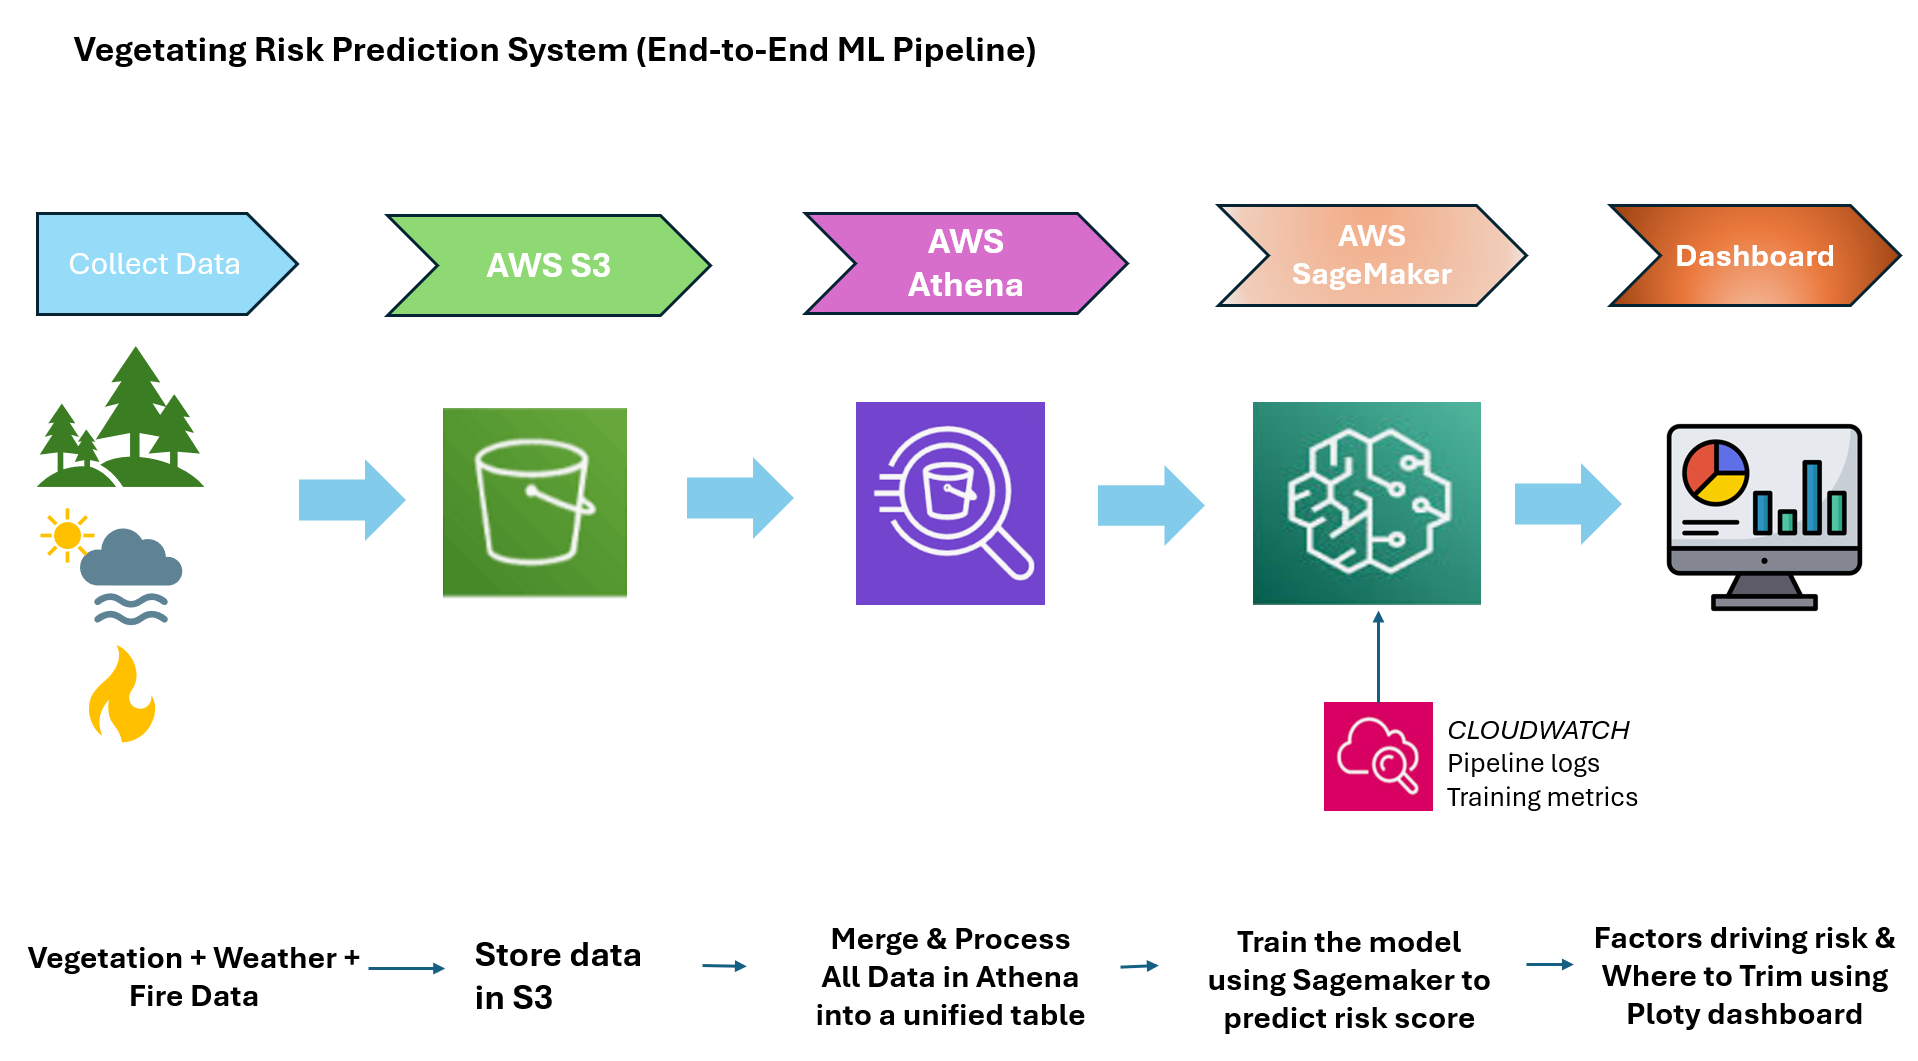

In [2]:
from IPython.display import Image, display

display(Image(filename="C:/Users/shesh/OneDrive/Desktop/ADS-508-Final-Project/ADS-508-Final-Project/images/architectural_dgm.PNG"))

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import boto3
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
from meteostat import Stations, Daily
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import json
import re
import tarfile 
import xgboost as xgb_lib
from pyathena import connect
import warnings
warnings.filterwarnings("ignore")
import sagemaker
from sagemaker.inputs import TrainingInput
from sagemaker import image_uris
from sagemaker.serializers import CSVSerializer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,accuracy_score, precision_score,recall_score, f1_score,ConfusionMatrixDisplay)
                                

# Connect SageMaker to S3

In [ ]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

athena-results/
processed/
processed/forest/combined_forest_data.csv
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_PLOT.csv
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/weather/
raw/weather/california_weather_data.csv


The datasets used in this project were originally downloaded from public government data sources- the U.S. Forest Service (FIA), CAL FIRE wildfire records and NOAA weather data accessed through the Meteostat library. After downloading, the files were manually uploaded to an Amazon S3 bucket. The datasets are accessed from Amazon S3 using SageMaker Studio notebooks for exploration and further processing.

# Load FIA(forest vegetation data) from S3

The FIA forest vegetation dataset consists of four tables: subplot information,plot information, tree characteristics, and biomass measurements. These files are stored in Amazon S3 and loaded into the SageMaker notebook for further analysis. 

In [ ]:
#file path for FIA forest datasets inside S3 bucket
subplot_path = "s3://vegetation-risk-ml/raw/forest/CA_SUBPLOT.csv"
tree_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE.csv"
biomass_path = "s3://vegetation-risk-ml/raw/forest/CA_TREE_REGIONAL_BIOMASS.csv"
plot_path = "s3://vegetation-risk-ml/raw/forest/CA_PLOT.csv"

In [ ]:
# Load the CSV file from S3 into a pandas DataFrame
subplot = pd.read_csv(subplot_path, low_memory=False)
subplot.head(3)

,CN,PLT_CN,PREV_SBP_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,SUBP_STATUS_CD,...,GROUND_TRAN_PTS_OTHER_RMRS,GROUND_TRAN_PTS_PEIS_RMRS,GROUND_TRAN_PTS_ROAD_RMRS,GROUND_TRAN_PTS_ROCK_RMRS,GROUND_TRAN_PTS_TRIS_RMRS,GROUND_TRAN_PTS_VEG_RMRS,GROUND_TRAN_PTS_WATER_RMRS,GROUND_TRAN_PTS_WOOD_RMRS,PREV_STATUSCD_RMRS,ROOTSEVCD_RMRS
0,59015,11839,NaN,1994,6,1,15,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,59042,11839,NaN,1994,6,1,15,1,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,59068,11839,NaN,1994,6,1,15,1,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Load the tree dataset from the specified file path into a pandas DataFrame.
trees = pd.read_csv(tree_path, low_memory=False)
trees.head(3)

,CN,PLT_CN,PREV_TRE_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,TREE,...,DRYBIO_STUMP_BARK,DRYBIO_BOLE_BARK,DRYBIO_BRANCH,DRYBIO_FOLIAGE,DRYBIO_SAWLOG_BARK,PREV_ACTUALHT_FLD,PREV_HT_FLD,UTILCLCD,SPCD_ID_CD,ABNORMAL_TERMINATION
0,675267,11839,NaN,1994,6,1,15,1,1,675267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,675268,11839,NaN,1994,6,1,15,1,1,675268,...,17.718832,469.383932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,675269,11839,NaN,1994,6,1,15,1,1,675269,...,10.354492,143.559569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Load the biomass dataset from the specified file path into a pandas DataFrame
biomass = pd.read_csv(biomass_path, low_memory=False)
biomass.head(3)

,TRE_CN,STATECD,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,CREATED_BY,CREATED_DATE,CREATED_IN_INSTANCE,MODIFIED_BY,MODIFIED_DATE,MODIFIED_IN_INSTANCE,REGIONAL_DRYBIOSL
0,44784050020004,6,181.351518,94.186487,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,NaN
1,44784051020004,6,244.463259,167.318417,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,152.313767
2,44784052020004,6,356.127994,204.940133,RWANEK,2012-07-26 14:10:00,20004,FSJASONBROWN,2020-07-11 23:46:37,290487,187.352578


In [ ]:
##load plot dataset from S3 into pandas DataFrame
plot = pd.read_csv(plot_path, low_memory=False)
plot.head(3)

,CN,SRV_CN,CTY_CN,PREV_PLT_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,PLOT_STATUS_CD,...,MANUAL_RMRS,PAC_ISLAND_PNWRS,PLOT_SEASON_NERS,PREV_MICROPLOT_LOC_RMRS,PREV_PLOT_STATUS_CD_RMRS,REUSECD1,REUSECD2,REUSECD3,GRND_LYR_SAMPLING_STATUS_CD,GRND_LYR_SAMPLING_METHOD_CD
0,11839,153648000020004,9010497,NaN,1994,6,1,15,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11840,153648000020004,9010497,NaN,1994,6,1,15,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11841,153648000020004,9010497,NaN,1994,6,1,15,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#check data structure of subplot dataset
subplot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178917 entries, 0 to 178916
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CN                             178917 non-null  int64  
 1   PLT_CN                         178917 non-null  int64  
 2   PREV_SBP_CN                    3384 non-null    float64
 3   INVYR                          178917 non-null  int64  
 4   STATECD                        178917 non-null  int64  
 5   UNITCD                         178917 non-null  int64  
 6   COUNTYCD                       178917 non-null  int64  
 7   PLOT                           178917 non-null  int64  
 8   SUBP                           178917 non-null  int64  
 9   SUBP_STATUS_CD                 178917 non-null  int64  
 10  POINT_NONSAMPLE_REASN_CD       9005 non-null    float64
 11  MICRCOND                       155600 non-null  float64
 12  SUBPCOND                      

In [ ]:
#check data structure of plot dataset
plot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43814 entries, 0 to 43813
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CN                              43814 non-null  int64  
 1   SRV_CN                          43814 non-null  int64  
 2   CTY_CN                          43814 non-null  int64  
 3   PREV_PLT_CN                     22257 non-null  float64
 4   INVYR                           43814 non-null  int64  
 5   STATECD                         43814 non-null  int64  
 6   UNITCD                          43814 non-null  int64  
 7   COUNTYCD                        43814 non-null  int64  
 8   PLOT                            43814 non-null  int64  
 9   PLOT_STATUS_CD                  43814 non-null  int64  
 10  PLOT_NONSAMPLE_REASN_CD         2051 non-null   float64
 11  MEASYEAR                        43814 non-null  int64  
 12  MEASMON                         

In [ ]:
#check data structure of tree dataset
trees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446320 entries, 0 to 446319
Columns: 198 entries, CN to ABNORMAL_TERMINATION
dtypes: float64(181), int64(13), object(4)
memory usage: 674.2+ MB


In [ ]:
#check data structure of biomass dataset
biomass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390955 entries, 0 to 390954
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   TRE_CN                390955 non-null  int64  
 1   STATECD               390955 non-null  int64  
 2   REGIONAL_DRYBIOT      316455 non-null  float64
 3   REGIONAL_DRYBIOM      329615 non-null  float64
 4   CREATED_BY            390955 non-null  object 
 5   CREATED_DATE          390955 non-null  object 
 6   CREATED_IN_INSTANCE   390955 non-null  int64  
 7   MODIFIED_BY           390955 non-null  object 
 8   MODIFIED_DATE         390955 non-null  object 
 9   MODIFIED_IN_INSTANCE  390955 non-null  int64  
 10  REGIONAL_DRYBIOSL     137020 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 32.8+ MB


#### Merge tree,plot,biomass and subplot dataset

The four FIA datasets are merged to create a unified forest vegetation dataset. The merge connects tree measurements with subplot environmental characteristics and biomass estimates.

In [ ]:
#Merge trees and subplot.To save memory, we will choose needed columns only
combined_forest = trees[["CN", "PLT_CN", "DIA", "HT", "SPCD", "STATUSCD"]].merge(subplot[["PLT_CN", "SLOPE", "ASPECT"]],on="PLT_CN",how="left")

#Merge the resulting dataframe with biomass dataframe on tree identifier.Again, select needed columns to save memory
combined_forest = combined_forest.merge(biomass[["TRE_CN", "REGIONAL_DRYBIOT", "REGIONAL_DRYBIOM"]],left_on="CN",right_on="TRE_CN",how="left")

plot_clean = plot[["CN", "LAT", "LON", "COUNTYCD"]].rename(columns={"CN": "PLT_CN"})

# Merge plot 
combined_forest = combined_forest.merge(plot_clean, on="PLT_CN", how="left")
# Remove duplicates
combined_forest = combined_forest.drop_duplicates()

#Check the resulting dataframe
print("Merged forest dataset shape:", combined_forest.shape)
combined_forest.head()

Merged forest dataset shape: (1687167, 14)


,CN,PLT_CN,DIA,HT,SPCD,STATUSCD,SLOPE,ASPECT,TRE_CN,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM,LAT,LON,COUNTYCD
0,675267,11839,3.9,43.0,631.0,1,50.0,225.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
2,675267,11839,3.9,43.0,631.0,1,60.0,225.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
4,675267,11839,3.9,43.0,631.0,1,40.0,180.0,675267.0,NaN,0.000000,41.478172,-123.946777,15
5,675268,11839,24.1,95.0,202.0,1,50.0,225.0,675268.0,NaN,2835.999965,41.478172,-123.946777,15
7,675268,11839,24.1,95.0,202.0,1,60.0,225.0,675268.0,NaN,2835.999965,41.478172,-123.946777,15


In [ ]:
#Missing values
(combined_forest.isnull().mean() * 100).round(2)

CN                   0.00
PLT_CN               0.00
DIA                  7.44
HT                   7.44
SPCD                 0.00
STATUSCD             0.00
SLOPE                2.49
ASPECT               2.49
TRE_CN              12.95
REGIONAL_DRYBIOT    27.90
REGIONAL_DRYBIOM    24.81
LAT                  0.00
LON                  0.00
COUNTYCD             0.00
dtype: float64

In [ ]:
combined_forest[['DIA','HT','SLOPE','REGIONAL_DRYBIOT','REGIONAL_DRYBIOM']].describe().round(2)

,DIA,HT,SLOPE,REGIONAL_DRYBIOT,REGIONAL_DRYBIOM
count,1561713.00,1561714.00,1645204.00,1216483.00,1268576.00
mean,14.70,57.82,37.88,2518.91,1773.81
std,11.92,39.81,22.90,6170.25,4012.51
min,1.00,1.00,0.00,0.42,0.00
25%,6.30,28.00,20.00,133.06,88.50
50%,10.00,46.00,35.00,394.91,312.13
75%,22.30,80.00,55.00,2485.09,1970.00
max,212.10,325.00,155.00,582558.91,347081.59


In [ ]:
#Save this merged dataframe to S3 for future use
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/combined_forest_data.csv", index=False)

# Load CALFIRE dataset from S3

The CAL FIRE dataset contains wildfire perimeter records for California, originaly downloaded from public website and uploaded manully into S3 in raw/fire folder.This dataset provides information on fire location, cause, start date, and burned area.

In [ ]:
# Path to wildfire dataset stored in S3
fire_path = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"

# Load wildfire dataset
fire = pd.read_csv(fire_path)

# Display dataset shape and rows
print("Fire dataset shape:", fire.shape)
fire.head(3)

Fire dataset shape: (3372, 23)


,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,incident_latitude,incident_type,incident_id,incident_url,incident_date_extinguished,incident_dateonly_extinguished,incident_dateonly_created,is_active,calfire_incident,notification_desired
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,40.774000,NaN,2ca11d45-8139-4c16-8af0-880d99b21e82,https://www.fire.ca.gov/incidents/2017/10/31/b...,2018-01-09T13:46:00Z,2018-01-09,2017-10-31,N,False,False
1,Pala Fire,Y,2020-09-16T14:07:35Z,2009-05-24T14:56:00Z,CAL FIRE San Diego Unit,NaN,San Diego,"Hwy 76 and Pala Temecula, northwest of Pala",122.0,100.0,...,1.000000,Wildfire,8f61f461-552d-4538-b186-35ab030da416,https://www.fire.ca.gov/incidents/2009/5/24/pa...,2009-05-25T00:00:00Z,2009-05-25,2009-05-24,N,True,False
2,River Fire,Y,2022-10-24T11:39:23Z,2013-02-24T08:16:00Z,CAL FIRE San Bernardino Unit,NaN,Inyo,"south of Narrow Gauge Rd & north of Hwy 136, e...",407.0,100.0,...,36.602575,NaN,094719ba-a47b-4abb-9ec5-a506b2b9fd23,https://www.fire.ca.gov/incidents/2013/2/24/ri...,2013-02-28T20:00:00Z,2013-02-28,2013-02-24,N,True,False


In [ ]:
#Basic structure of fire dataset
print(fire.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3372 entries, 0 to 3371
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   incident_name                     3372 non-null   object 
 1   incident_is_final                 3372 non-null   object 
 2   incident_date_last_update         3372 non-null   object 
 3   incident_date_created             3372 non-null   object 
 4   incident_administrative_unit      3307 non-null   object 
 5   incident_administrative_unit_url  0 non-null      float64
 6   incident_county                   3362 non-null   object 
 7   incident_location                 3372 non-null   object 
 8   incident_acres_burned             3319 non-null   float64
 9   incident_containment              3320 non-null   float64
 10  incident_control                  119 non-null    object 
 11  incident_cooperating_agencies     1691 non-null   object 
 12  incide

In [ ]:
#missing values in fire dataset
print(fire.isnull().sum())

incident_name                          0
incident_is_final                      0
incident_date_last_update              0
incident_date_created                  0
incident_administrative_unit          65
incident_administrative_unit_url    3372
incident_county                       10
incident_location                      0
incident_acres_burned                 53
incident_containment                  52
incident_control                    3253
incident_cooperating_agencies       1681
incident_longitude                     0
incident_latitude                      0
incident_type                       1234
incident_id                            0
incident_url                           0
incident_date_extinguished           741
incident_dateonly_extinguished       741
incident_dateonly_created              0
is_active                              0
calfire_incident                       0
notification_desired                   0
dtype: int64


In [ ]:
#duplicated values in fire dataset
print(fire.duplicated().sum())

0


# Load Weather Data Using Meteostat

Weather stations across California are retrieved using the Meteostat API. These stations provide historical weather measurements such as temperature and precipitation.

In [ ]:

# get stations
stations = Stations().region('US', 'CA').fetch(200).reset_index()
stations = stations[['id', 'latitude', 'longitude']]
stations.columns = ['station', 'lat', 'lon']

# Weather download
start, end = datetime(2015,1,1), datetime(2026,1,1)

weather_data = []
for s in stations['station'][:100]:
    try:
        data = Daily(s, start, end).fetch()
        if not data.empty:
            data = data.reset_index()
            data['station'] = s
            weather_data.append(data)
    except Exception as e:
        print(f"Error for station {s}: {e}")


weather = pd.concat(weather_data, ignore_index=True)

#Merge weather data with station info. 
weather = weather.merge(stations, on='station', how='left')
#Select relevant columns to save memory
weather = weather[['time','tavg', 'prcp', 'wspd', 'station', 'lat', 'lon','pres','tmin','tmax']]
weather["time"] = pd.to_datetime(weather["time"]).dt.date
#drop missing values
weather = weather.dropna(subset= ["lat", "lon"])

print(f"Total: {len(weather)} records from {weather['station'].nunique()} stations")
print(weather.head())

Total: 309116 records from 91 stations
         time  tavg  prcp  wspd station      lat       lon  pres  tmin  tmax
0  2020-11-05  13.5   NaN   NaN   69007  36.6815 -121.7617   NaN   8.0  27.0
1  2020-11-06  12.1   NaN   NaN   69007  36.6815 -121.7617   NaN   8.0  15.0
2  2020-11-07   9.9   NaN   NaN   69007  36.6815 -121.7617   NaN   6.0  13.0
3  2020-11-08   9.1   NaN   NaN   69007  36.6815 -121.7617   NaN   2.0  12.0
4  2020-11-09   5.5   NaN   NaN   69007  36.6815 -121.7617   NaN  -1.0  13.0


In [ ]:
#Summary statistics of weather data
weather[["tavg","prcp","wspd","pres"]].describe().round(2)

,tavg,prcp,wspd,pres
count,301803.00,259384.00,297457.00,263940.00
mean,16.65,1.13,10.89,1015.32
std,7.21,6.23,6.21,4.98
min,-28.70,0.00,0.00,977.90
25%,11.70,0.00,6.80,1012.00
50%,15.80,0.00,9.40,1014.90
75%,21.10,0.00,13.30,1018.50
max,43.70,1265.30,125.60,1045.90


The average temperature across weather stations is 16 degC, with values ranging from −28 degC to 43 degC.Precipitation has a mean of 1.13 mm and a median of 0 mm, indicating that most observations experience little or no rainfall. Wind speeds average is 10.65 km/h with a maximum of 156 km/h, and atmospheric pressure shows a mean of 1015 hPa.

In [ ]:
#missing values
print(weather.isnull().sum())

time           0
tavg        7313
prcp       49732
wspd       11659
station        0
lat            0
lon            0
pres       45176
tmin         624
tmax         624
dtype: int64


In [ ]:
# save the weather data to S3 for future use
weather.to_csv("s3://vegetation-risk-ml/raw/weather/california_weather_data.csv", index=False)

# INITIAL DATA EXPLORATION

### What are the distributions and relationships among key weather variables (temperature, precipitation,atmospheric pressure and wind speed) across California weather stations?
    

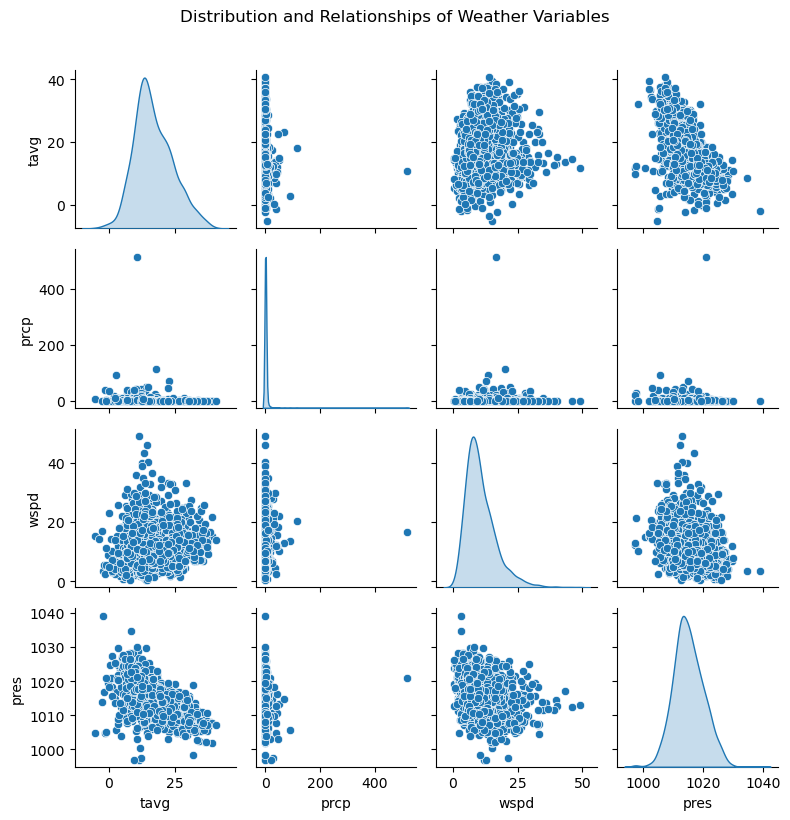

In [ ]:
#select key weather variables for analysis
weather_subset = weather[["tavg","prcp","wspd","pres"]]
#plot pairwise relationships and distributions of weather variables using seaborn
sns.pairplot(weather_subset.sample(2000),diag_kind="kde", height=2)

plt.suptitle("Distribution and Relationships of Weather Variables", y=1.02)
plt.tight_layout()
plt.show()

The pairplot shows the distribution and relationships between temperature, precipitation,presssure and wind speed across California weather stations. The temperature variable show positive correlation. Temperature and pressure appears normally distributed, precipitation shows right-skewed, indicating that most days have little or no rainfall which can be a risk factor for dry vegetation. Wind speed shows right skewed with very few high speed winds. The scatter relationships suggest weak correlations between these variables, indicating that temperature, precipitation, pressure and wind speed vary relatively independently across the dataset.

### Which forest and terrain variables(slope and Aspect) are most strongly associated with vegetation biomass?

Identifying which forest(diameter and height) and terrain(slope and aspect) variables are most strongly related with vegetation biomass is important because these factors influence sunlight exposure, moisture availability, and soil conditions, which ultimately affect vegetation growth.Forests with larger trees and higher biomass provide more fuel, while terrain influence how quickly fires spread and how dry the vegetation becomes.

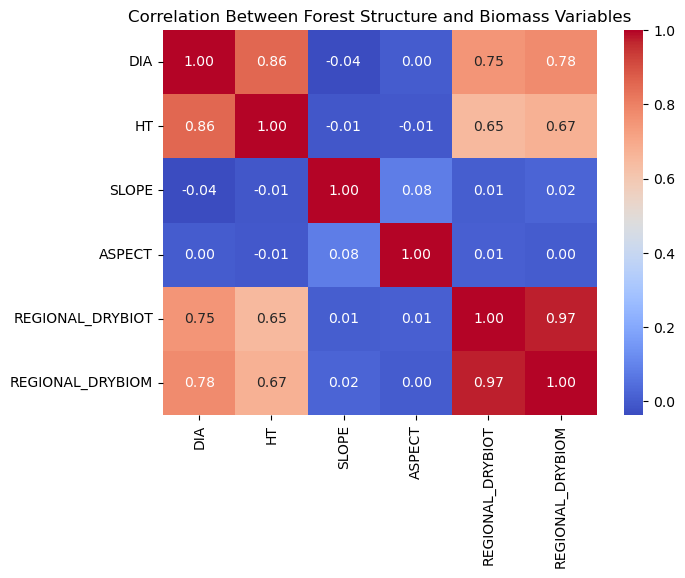

In [ ]:
plt.figure(figsize=(7,5))
#select key forest structure and biomass variables for correlation analysis
corr_features = combined_forest[['DIA','HT','SLOPE','ASPECT','REGIONAL_DRYBIOT','REGIONAL_DRYBIOM']]
#plot heatmap of correlations between selected forest structure and biomass variables
sns.heatmap(corr_features.corr(),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Between Forest Structure and Biomass Variables")
plt.show()

The correlation heatmap shows the relationships between tree characteristics(tee diameter,tree height), terrain variables, and vegetation biomass. 

Tree diameter and height show positive correlations with biomass variables, suggesting that larger trees contribute to higher vegetation fuel loads.So areas with many large trees may require more vegetation management to reduce wildfire fuel accumulation.

REGIONAL_DRYBIOT and REGIONAL_DRYBIOM shows strongly correlated(multicollinearity).Because these variables represent similar measurements of dry biomass, one of them may be sufficient for modeling purposes.

Steeper slopes combined with high biomass could increase wildfire spread risk.These areas require targeted vegetation trimming to reduce potential fire hazards.

### Is wildfire size distribution skewed toward extreme events?

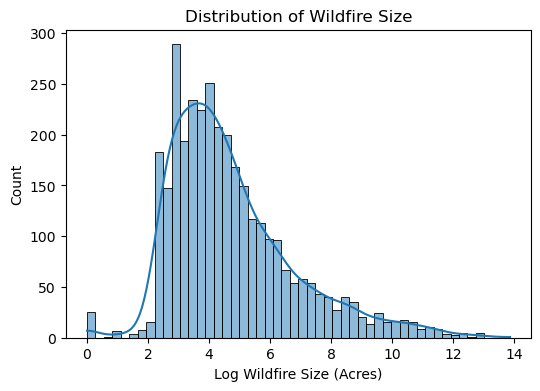

In [ ]:

plt.figure(figsize=(6,4))
#plot histogram of wildfire size distribution using log scale to handle skewness
sns.histplot(np.log1p(fire["incident_acres_burned"]),kde=True, bins=50)

plt.xlabel("Log Wildfire Size (Acres)")
plt.title("Distribution of Wildfire Size")
plt.show()

Plot shows Wildfire data is right-skewed.Most fires burn small areas, while a small number of large fires account for a significant portion of total burned land. This pattern is common in wildfire datasets and highlights the importance of identifying conditions that lead to extreme fire events.

### What is the distribution of vegetation biomass across forest plots?

This directly uses your forest dataset and helps understand fuel load, which is important for wildfire risk.

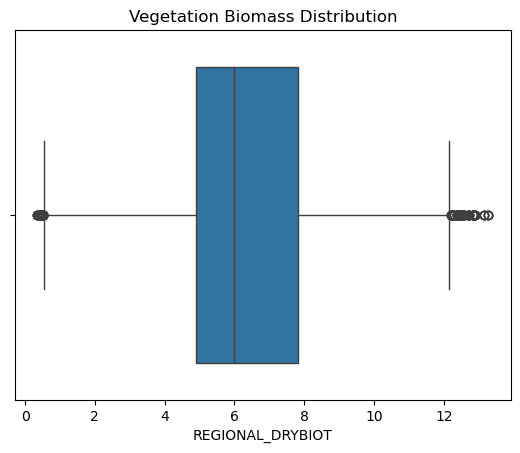

In [ ]:
#plot boxplot of regional dry biomass distribution
sns.boxplot(x=np.log1p(combined_forest["REGIONAL_DRYBIOT"].dropna()))

plt.title("Vegetation Biomass Distribution")
plt.show()

The boxplot shows the distribution of vegetation biomass (REGIONAL_DRYBIOT). The median value is around 6, while the interquartile range lies between 5 and 8. The whiskers extend from about 0.5 to around 12,showing the spread of the data. A few outliers above 12 suggest that some regions have unusually high vegetation biomass compared to the majority of the dataset.These high-biomass areas may represent dense vegetation and which can act as larger fuel sources and can increase wildfire intensity if ignition occurs.

### Where are wildfire incidents geographically concentrated across California?

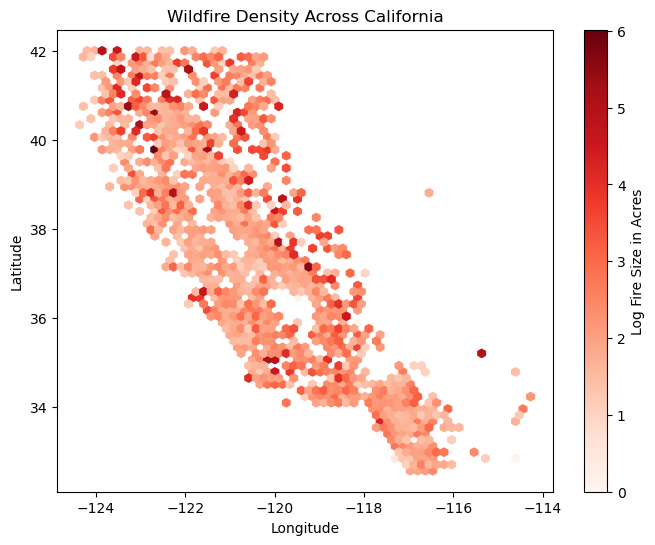

In [ ]:
plt.figure(figsize=(8,6))
#remove invalid coordinates
fire_plt = fire[(fire["incident_longitude"].between(-125,-114)) & (fire["incident_latitude"].between(32,42))]
#plot the hexbin
scatter = plt.hexbin(x=fire_plt["incident_longitude"],y=fire_plt["incident_latitude"],C=np.log10(fire_plt["incident_acres_burned"] + 1),gridsize=60,cmap="Reds",mincnt=1)
bar = plt.colorbar(scatter)
bar.set_label("Log Fire Size in Acres")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Wildfire Density Across California")
plt.show()

The hexbin plot shows the spatial distribution of wildfire incidents across California using geographic coordinates. The color gradient indicates the logarithm of fire size in acres, with darker hexagons indicating locations where larger fires occurred. Larger fires appear in several parts of Northern California and some areas of Southern California, while the Central Valley shows fewer wildfire incidents.These spatial patterns can help identify regions where vegetation management and tree trimming should be prioritized to reduce wildfire risk.

### How does the number of wildfire incidents vary across different months of the year in California?

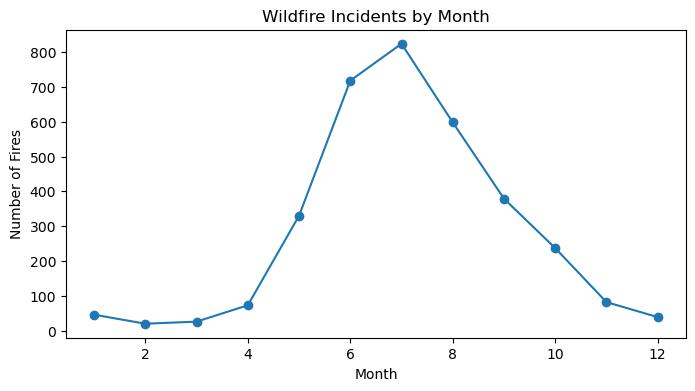

In [ ]:

# Convert to datetime
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"])

# Extract month
fire["month"] = fire["incident_date_created"].dt.month

# Count fires per month
fires_per_month = fire.groupby("month").size()

# Plot
plt.figure(figsize=(8,4))
fires_per_month.plot(kind="line", marker="o")

plt.xlabel("Month")
plt.ylabel("Number of Fires")
plt.title("Wildfire Incidents by Month")
plt.show()

The number of fires peaks during the summer months, particularly in July and August, before gradually declining in the fall. This pattern suggests that warmer temperatures and drier vegetation conditions during summer months contribute to higher wildfire activity in California.

# Connect SageMaker to S3

In [ ]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)

#Print the names of the files in the bucket
for obj in response['Contents']:
    print(obj['Key'])

athena-results/
processed/
processed/fire/fire_cleaned.csv
processed/forest/forest_cleaned.csv
processed/weather/weather_cleaned.csv
raw/
raw/fire/
raw/fire/California_Historic_Fire_data.csv
raw/forest/
raw/forest/CA_PLOT.csv
raw/forest/CA_SUBPLOT.csv
raw/forest/CA_TREE.csv
raw/forest/CA_TREE_REGIONAL_BIOMASS.csv
raw/forest/combined_forest_data.csv
raw/weather/
raw/weather/california_weather_data.csv


# **DATA PREPARATION**

**Define s3 path**

In [ ]:
#Define S3 fi
forest_path  = "s3://vegetation-risk-ml/raw/forest/combined_forest_data.csv"
fire_path    = "s3://vegetation-risk-ml/raw/fire/California_Historic_Fire_data.csv"
weather_path = "s3://vegetation-risk-ml/raw/weather/california_weather_data.csv"

**Load datasets**

In [ ]:
combined_forest = pd.read_csv(forest_path, low_memory=False)
print("Forest dataset shape :", combined_forest.shape)
fire = pd.read_csv(fire_path, low_memory=False)
print("Fire dataset shape :", fire.shape)
weather = pd.read_csv(weather_path, low_memory=False)
print("Weather dataset shape :", weather.shape)

print("Datasets loaded successfully")

Forest dataset shape : (1687167, 14)
Fire dataset shape : (3372, 23)
Weather dataset shape : (309116, 10)
Datasets loaded successfully


# DATA CLEANING AND PREPROCESSING

### Forest dataset cleaning

We will handle missing values and drop the unnecessary columns so that the dataset represents only relevent columns which directly affects trimming prioritization.This stage will prepare our dataset for integration.

Here only variables that influence vegetation density and wildfire potential are retained.

**Drop unnecessary columns**

 We drop plt_cn,spsd to avoid noise in the data and reduce memory usage.From exploration,we know that REGIONAL_DRYBIOT and REGIONAL_DRYBIOM are highly correlated so we keep only one of them.

In [ ]:
#select most relevent column 
combined_forest=combined_forest[["DIA", "HT", "SLOPE", "REGIONAL_DRYBIOT","LAT", "LON","COUNTYCD"]]  #tree size,height,terrain,direction,biomass

#check the shape of the dataset
combined_forest.shape

(1687167, 7)

**Remove Duplicates**

In [ ]:
#remove duplicates
combined_forest = combined_forest.drop_duplicates()
# Verify
print("Duplicates remaining:", combined_forest.duplicated().sum())

Duplicates remaining: 0


**Handle missing valus**

To handle missing values, median is used because biomass is skewed and avoids distortion from outliers.

In [ ]:
#fill missing values for biomass
combined_forest = combined_forest.dropna(subset=["LAT", "LON"])
combined_forest["REGIONAL_DRYBIOT"] = combined_forest["REGIONAL_DRYBIOT"].fillna(combined_forest["REGIONAL_DRYBIOT"].median())
combined_forest["SLOPE"] = combined_forest["SLOPE"].fillna(combined_forest["SLOPE"].median())
combined_forest["DIA"] = combined_forest["DIA"].fillna(combined_forest["DIA"].median()) 
combined_forest["HT"] = combined_forest["HT"].fillna(combined_forest["HT"].median())                                                     

# Verify
print("Missing values:\n", combined_forest.isnull().sum())

Missing values:
 DIA                 0
HT                  0
SLOPE               0
REGIONAL_DRYBIOT    0
LAT                 0
LON                 0
COUNTYCD            0
dtype: int64


**Handle outlier**

In [ ]:
#handle unrealistic value of tree diameter and height
combined_forest = combined_forest[(combined_forest["DIA"] > 0) & (combined_forest["HT"] > 0)]

In [ ]:
#Verify the resulting dataset
combined_forest.head()

,DIA,HT,SLOPE,REGIONAL_DRYBIOT,LAT,LON,COUNTYCD
0,3.9,43.0,50.0,404.669221,41.478172,-123.946777,15
1,3.9,43.0,60.0,404.669221,41.478172,-123.946777,15
2,3.9,43.0,40.0,404.669221,41.478172,-123.946777,15
3,24.1,95.0,50.0,404.669221,41.478172,-123.946777,15
4,24.1,95.0,60.0,404.669221,41.478172,-123.946777,15


### Fire dataset cleaning

Here we will keep valid geographic coordinates and meaningful fire size measurements only.

**Select Relevent Columns**

In [ ]:
#select relevant features only
fire=fire[["incident_acres_burned", "incident_longitude", "incident_latitude", "incident_date_created","incident_county"]]

In [ ]:
#remove fires with invalid coordinates (outside California)
fire = fire[(fire["incident_latitude"].between(32, 42)) &(fire["incident_longitude"].between(-124, -114))]

#Remove fires with missing coordinates
fire = fire.dropna(subset=["incident_latitude", "incident_longitude"])

#Remove fires with zero size
fire = fire[fire["incident_acres_burned"] > 0]

#Convert datecolumn to datetime and remove timezone
fire["incident_date_created"] = pd.to_datetime(fire["incident_date_created"], errors="coerce").dt.date

# Remove missing county
fire = fire.dropna(subset=["incident_county", "incident_date_created"])

# Reset index
fire = fire.reset_index(drop=True)

#display results
print("Cleaned fire dataset shape:", fire.shape)


Cleaned fire dataset shape: (3253, 5)


In [ ]:
#check for any remaining missing value
print(fire.isnull().sum())
fire.head()

incident_acres_burned    0
incident_longitude       0
incident_latitude        0
incident_date_created    0
incident_county          0
dtype: int64


,incident_acres_burned,incident_longitude,incident_latitude,incident_date_created,incident_county
0,37.0,-122.309000,40.774000,2017-10-31,Shasta
1,407.0,-118.016510,36.602575,2013-02-24,Inyo
2,30.0,-116.941311,34.288877,2013-04-20,San Bernardino
3,274.0,-119.635004,37.116295,2013-04-30,Madera
4,6896.0,-121.595555,40.190062,2013-05-01,Tehama


#### Weather dataset cleaning

We will select temperature ,precipitation and wind speed that influence vegetation growth and fire risk. Here missing values are imputed to ensure consistent weather observations.

In [ ]:

# Fill missing rainfall
weather["prcp"] = weather["prcp"].fillna(0)

# Fill wind speed
weather["wspd"] = weather["wspd"].fillna(weather["wspd"].median())

# Remove unrealistic temperatures
weather = weather[(weather["tavg"] > -40) & (weather["tavg"] < 60)]

# Fill missing average temperature
weather["tavg"] = weather["tavg"].fillna((weather["tmin"] + weather["tmax"])/2)

# We can drop tmax and tmin as we have tavg, and they are highly correlated
#also we will drop pressure because of week correlation
weather = weather[['time','tavg', 'prcp', 'wspd', 'station', 'lat', 'lon']]

In [ ]:
#Verify the resulting dataset
print("Cleaned weather dataset shape:", weather.shape)
#check for any remaining missing values
print("Missing values in each column:")
print(weather.isnull().sum())
print("First few rows of the cleaned dataset:")
weather.head()

Cleaned weather dataset shape: (301803, 7)
Missing values in each column:
time       0
tavg       0
prcp       0
wspd       0
station    0
lat        0
lon        0
dtype: int64
First few rows of the cleaned dataset:


,time,tavg,prcp,wspd,station,lat,lon
0,2020-11-05,13.6,0.0,9.4,69007,36.6815,-121.7617
1,2020-11-06,12.0,0.0,9.4,69007,36.6815,-121.7617
2,2020-11-07,10.0,0.0,9.4,69007,36.6815,-121.7617
3,2020-11-08,9.0,0.0,9.4,69007,36.6815,-121.7617
4,2020-11-09,5.7,0.0,9.4,69007,36.6815,-121.7617


#### **Save the cleaned dataset to S3**

The cleaned datasets are then store back in S3 in separete folder processed/ for future analysis.

In [ ]:
combined_forest.to_csv("s3://vegetation-risk-ml/processed/forest/forest_cleaned.csv",index=False)

fire.to_csv("s3://vegetation-risk-ml/processed/fire/fire_cleaned.csv",index=False)

weather.to_csv("s3://vegetation-risk-ml/processed/weather/weather_cleaned.csv",index=False)

print("Cleaned datasets saved successfully in S3")

Cleaned datasets saved successfully in S3


Next,to merge all three cleaned datasets, we are using Athena.

Athena is used to perform  data merging of all three cleaned datasets and aggregation directly on S3 without loading large datasets into memory.This resolves the high memory usage and slow processing.The final unified feature table will be used for model training and dashboard visualization.

# Connect SageMaker to Athena

In [ ]:
#Create folfer in S3 to save athena results
s3 = boto3.client("s3")

s3.put_object(Bucket="vegetation-risk-ml",Key="athena-results/")
print("athena-results folder created in S3")

athena-results folder created in S3


In [ ]:
#verify the athena results folder is created
response = s3.list_objects_v2(Bucket="vegetation-risk-ml",Prefix="athena-results/")
print("Folder exists:", "athena-results/" in [obj["Key"] for obj in response.get("Contents", [])])

Folder exists: True


In [ ]:

#Query results are stored in s3 in this directory
s3_staging_dir = "s3://vegetation-risk-ml/athena-results/"

# Athena connection
conn = connect(s3_staging_dir=s3_staging_dir,region_name="us-east-1")

print("Connected to Athena")

Connected to Athena


# Create Table for Forest Dataset

In [ ]:
#drop old tables if exist
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.forest_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped if any")

Old table dropped if any


In [ ]:
#create forest table
forest_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.forest_cleaned (
    DIA DOUBLE,
    HT DOUBLE,
    SLOPE DOUBLE,
    REGIONAL_DRYBIOT DOUBLE,
    lat DOUBLE,
    lon DOUBLE,
    COUNTYCD INT
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/forest/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""

pd.read_sql(forest_query, conn)
print("Forest table created successfully")

Forest table created successfully


# Create Table for Weather Dataset

In [ ]:
#drop if table already exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.weather_cleaned
"""
pd.read_sql(drop_query, conn)
print("Old table dropped")

Old table dropped


In [ ]:
weather_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.weather_cleaned (
    time STRING,
    tavg DOUBLE,
    prcp DOUBLE,
    wspd DOUBLE,
    station STRING,
    lat DOUBLE,
    lon DOUBLE
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/weather/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(weather_query, conn)
print("Weather table created successfully")


Weather table created successfully


# Create Table for Fire Dataset

In [ ]:
#drop if table exists
drop_query = """
DROP TABLE IF EXISTS vegetation_ml.fire_cleaned
"""
pd.read_sql(drop_query, conn)

""


In [ ]:
fire_query = """
CREATE EXTERNAL TABLE IF NOT EXISTS vegetation_ml.fire_cleaned (
    incident_acres_burned DOUBLE,
    lon DOUBLE,
    lat DOUBLE,
    incident_date_created STRING,
    incident_county STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
LOCATION 's3://vegetation-risk-ml/processed/fire/'
TBLPROPERTIES ("skip.header.line.count"="1","use.null.for.invalid.data"="true");
"""
pd.read_sql(fire_query, conn)
print("Fire table created successfully")

Fire table created successfully


**Verify tables**

In [ ]:

# Check if tables exist and data is accessible
for table in ["forest_cleaned", "weather_cleaned", "fire_cleaned"]:
    query = f"SELECT * FROM vegetation_ml.{table} LIMIT 5"
    df = pd.read_sql(query, conn)
    print(f"Sample data from {table}:")
    print(df.head())
    print("\n")

Sample data from forest_cleaned:
    dia    ht  slope  regional_drybiot        lat         lon  countycd
0   3.9  43.0   50.0        404.669221  41.478172 -123.946777        15
1   3.9  43.0   60.0        404.669221  41.478172 -123.946777        15
2   3.9  43.0   40.0        404.669221  41.478172 -123.946777        15
3  24.1  95.0   50.0        404.669221  41.478172 -123.946777        15
4  24.1  95.0   60.0        404.669221  41.478172 -123.946777        15


Sample data from weather_cleaned:
         time  tavg  prcp  wspd station      lat       lon
0  2020-11-05  13.6   0.0   9.4   69007  36.6815 -121.7617
1  2020-11-06  12.0   0.0   9.4   69007  36.6815 -121.7617
2  2020-11-07  10.0   0.0   9.4   69007  36.6815 -121.7617
3  2020-11-08   9.0   0.0   9.4   69007  36.6815 -121.7617
4  2020-11-09   5.7   0.0   9.4   69007  36.6815 -121.7617


Sample data from fire_cleaned:
   incident_acres_burned         lon        lat incident_date_created  \
0                   37.0 -122.309000  4

# Create Unified Feature table in Athena

Now we create the final Feature table by merging all three tables. This final table becomes the single source of truth for modelling and dashboard analysis.

Drop if any table exist

In [ ]:
drop_query = "DROP TABLE IF EXISTS vegetation_ml.vegetation_risk_dataset"
pd.read_sql(drop_query, conn)
print("Old vegetation_risk_dataset table dropped if exists")

Old vegetation_risk_dataset table dropped if exists


The three datasets are merged in Athena using latitude and longitude as the geographic key, with the forest table as the base. Fire incidents are first aggregated into spatial grid buckets by rounding latitude and longitude values. This creates localized fire statistics such as fire count and fire size.

Each forest plot is then matched to the nearest fire grid point using a spatial proximity condition and distance calculation. Similarly, weather data is aggregated by station and month, and each forest plot is matched to the nearest weather station within a defined distance.

In both cases, a ROW_NUMBER() window function is used to select only the closest match for each forest plot. This ensures that each record is linked to a single relevant fire and weather observation.

The final result is a unified dataset where every forest record contains its own local fire history and nearby weather conditions, making it suitable for machine learning.

In [ ]:
create_query = """
CREATE TABLE vegetation_ml.vegetation_risk_dataset
WITH (
    format='PARQUET',
    external_location='s3://vegetation-risk-ml/final/'
) AS

-- FIRE DATA
WITH fire_points AS (
    SELECT
        lat AS fire_lat,
        lon AS fire_lon,
        incident_acres_burned,
        DATE_PARSE(incident_date_created, '%Y-%m-%d') AS fire_date,
        YEAR(DATE_PARSE(incident_date_created, '%Y-%m-%d')) AS fire_year,
        MONTH(DATE_PARSE(incident_date_created, '%Y-%m-%d')) AS fire_month
    FROM vegetation_ml.fire_cleaned
    WHERE incident_date_created IS NOT NULL
      AND incident_acres_burned > 0
      AND lat BETWEEN 32 AND 42
      AND lon BETWEEN -124 AND -114
),

fire_agg AS (
    SELECT
        ROUND(fire_lat, 2) AS lat_bucket,
        ROUND(fire_lon, 2) AS lon_bucket,
        COUNT(*) AS fire_count,
        MAX(incident_acres_burned) AS max_fire_size,
        AVG(incident_acres_burned) AS avg_fire_size,
        MAX(fire_date) AS last_fire_date,
        MAX(fire_year) AS last_fire_year,
        MAX(fire_month) AS fire_month
    FROM fire_points
    GROUP BY ROUND(fire_lat, 2), ROUND(fire_lon, 2)
),

-- FOREST CLEAN
forest_clean AS (
    SELECT DISTINCT
        DIA, HT, SLOPE, REGIONAL_DRYBIOT, lat, lon, COUNTYCD
    FROM vegetation_ml.forest_cleaned
    WHERE lat BETWEEN 32 AND 42
      AND lon BETWEEN -124 AND -114
      AND DIA > 0
      AND HT > 0
      AND REGIONAL_DRYBIOT > 0
),

-- WEATHER (STATION AND  MONTH)
weather_prepared AS (
    SELECT
        station,
        lat,
        lon,
        MONTH(CAST(time AS TIMESTAMP)) AS month,
        AVG(tavg) AS avg_temp,
        AVG(prcp) AS avg_rain,
        AVG(wspd) AS avg_wind
    FROM vegetation_ml.weather_cleaned
    WHERE tavg IS NOT NULL
      AND prcp IS NOT NULL
      AND wspd IS NOT NULL
      AND lat BETWEEN 32 AND 42
      AND lon BETWEEN -124 AND -114
    GROUP BY station, lat, lon, MONTH(CAST(time AS TIMESTAMP))
),

-- NEAREST FIRE MATCH 
fire_match AS (
    SELECT
        f.*,
        fa.fire_count,
        fa.max_fire_size,
        fa.avg_fire_size,
        fa.last_fire_year,
        fa.fire_month,

        -- Years since last fire
        COALESCE(YEAR(CURRENT_DATE) - fa.last_fire_year, 99) AS years_since_fire,

        -- Distance in miles
        SQRT(
            POWER((f.lat - fa.lat_bucket) * 69, 2) +
            POWER((f.lon - fa.lon_bucket) * 69 * COS(RADIANS(f.lat)), 2)
        ) AS fire_distance_miles,

        ROW_NUMBER() OVER (
            PARTITION BY f.lat, f.lon, f.DIA, f.HT
            ORDER BY
                POWER(f.lat - fa.lat_bucket, 2) +
                POWER(f.lon - fa.lon_bucket, 2)
        ) AS fire_rn

    FROM forest_clean f
    LEFT JOIN fire_agg fa
        ON ABS(f.lat - fa.lat_bucket) < 0.3
       AND ABS(f.lon - fa.lon_bucket) < 0.3
),

-- NEAREST WEATHER MATCH 
weather_match AS (
    SELECT
        fm.*,
        wp.avg_temp,
        wp.avg_rain,
        wp.avg_wind,

        SQRT(
            POWER((fm.lat - wp.lat) * 69, 2) +
            POWER((fm.lon - wp.lon) * 69 * COS(RADIANS(fm.lat)), 2)
        ) AS weather_distance_miles,

        ROW_NUMBER() OVER (
            PARTITION BY fm.lat, fm.lon, fm.DIA, fm.HT  
            ORDER BY
                POWER(fm.lat - wp.lat, 2) +
                POWER(fm.lon - wp.lon, 2)
        ) AS weather_rn

    FROM fire_match fm
    LEFT JOIN weather_prepared wp
        ON fm.fire_month = wp.month
       AND ABS(fm.lat - wp.lat) < 1.0
       AND ABS(fm.lon - wp.lon) < 1.0
)

-- FINAL DATASET
SELECT
    DIA,
    HT,
    SLOPE,
    REGIONAL_DRYBIOT,
    lat,
    lon,
    COUNTYCD,

    -- Fire features
    COALESCE(fire_count, 0) AS fire_count,
    COALESCE(max_fire_size, 0.0) AS max_fire_size,
    COALESCE(avg_fire_size, 0.0) AS avg_fire_size,
    COALESCE(years_since_fire, 99) AS years_since_fire,
    COALESCE(fire_month, 0) AS fire_month,
    COALESCE(fire_distance_miles, 999) AS fire_distance_miles,

    -- Weather features
    COALESCE(avg_temp, 14.2) AS avg_temp,
    COALESCE(avg_rain, 1.8) AS avg_rain,
    COALESCE(avg_wind, 6.3) AS avg_wind,
    COALESCE(weather_distance_miles, 999) AS weather_distance_miles

FROM weather_match
WHERE fire_rn = 1
  AND weather_rn = 1
  AND fire_distance_miles <= 50   
  AND weather_distance_miles <= 50;
"""

pd.read_sql(create_query, conn)
print("Unified feature table created successfully")  

Unified feature table created successfully


In [ ]:
weather_check = """
SELECT COUNT(*) AS total_stations,MIN(lat) AS min_lat, MAX(lat) AS max_lat,MIN(lon) AS min_lon, MAX(lon) AS max_lon
FROM vegetation_ml.weather_cleaned
"""
print(pd.read_sql(weather_check, conn))

   total_stations  min_lat  max_lat   min_lon   max_lon
0          301803  32.6167  41.7802 -124.2365 -114.6233


In [ ]:
fire_check = """
SELECT DISTINCT incident_county
FROM vegetation_ml.fire_cleaned
ORDER BY incident_county
LIMIT 20
"""
print(pd.read_sql(fire_check, conn))


                                 incident_county
0                                        Alameda
1                           Alameda, San Joaquin
2                                         Alpine
3                                         Amador
4                              Amador, Calaveras
5                              Amador, El Dorado
6                                          Butte
7          Butte, Plumas, Shasta, Lassen, Tehama
8                                  Butte, Tehama
9                                      Calaveras
10  Calaveras, San Joaquin, Stanislaus, Tuolumne
11                                        Colusa
12                                  Colusa, Lake
13                       Colusa, Lake, Mendocino
14                Colusa, Mendocino, Glenn, Lake
15                                  Contra Costa
16                                     Del Norte
17                                     El Dorado
18                     El Dorado, Alpine, Amador
19                  

In [ ]:
query = "SELECT * FROM vegetation_ml.vegetation_risk_dataset LIMIT 5"
vegetation_risk_dataset = pd.read_sql(query, conn)

vegetation_risk_dataset.head()

,dia,ht,slope,regional_drybiot,lat,lon,countycd,fire_count,max_fire_size,avg_fire_size,years_since_fire,fire_month,fire_distance_miles,avg_temp,avg_rain,avg_wind,weather_distance_miles
0,10.2,46.0,35.0,404.669221,32.677701,-116.727918,73,2,263.0,156.5,1,9,2.571301,21.564794,0.357678,11.297753,15.744269
1,5.2,21.0,0.0,73.837135,32.692853,-116.508686,73,1,25.0,25.0,11,7,1.103700,24.474194,0.135484,11.362007,5.792634
2,6.0,23.0,0.0,108.927059,32.692853,-116.508686,73,1,25.0,25.0,11,7,1.103700,24.474194,0.135484,11.362007,5.792634
3,3.3,23.0,0.0,27.219884,32.761664,-116.727392,73,1,16390.0,16390.0,6,9,2.244585,21.564794,0.357678,11.297753,18.134465
4,5.0,14.0,35.0,52.318863,32.761664,-116.727392,73,1,16390.0,16390.0,6,9,2.244585,21.564794,0.357678,11.297753,18.134465


**Load Final Feature Table from S3 into SageMaker**

The unified feature table (source of truth) created by Athena is loaded from the S3 final/ folder into SageMaker for feature engineering and model training.

In [ ]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/")
print("Shape:", vegetation_risk_data.shape)

Shape: (243820, 17)


# **Feature Engineering**

# Feature Creation

Here we will create new features and transform the existing features for our machine learning model.

**Fuel Mositure Risk**

This featutee captures vegetation dryness(hot weather and no rain).The higher value means drier the vegetation condition,which increase wildfire risk if ignition happens. Its calculated as fuel moisture risk=temperatue/(rainfall+1).

Area with high temperature and low rainfall are where dry vegetation accumulates.Such plots need to be trimmed first as a small ignition can trigger large fire.

In [ ]:
# Calculate fuel moisture risk as the ratio of average temperature to average rainfall,#=1 to avoid division by zero
vegetation_risk_data["fuel_moisture_risk"] = vegetation_risk_data["avg_temp"] / (vegetation_risk_data["avg_rain"] + 1)
vegetation_risk_data.value_counts("fuel_moisture_risk").head()

fuel_moisture_risk
25.457592    10997
11.324842     9427
29.801052     8911
22.383552     8761
10.186703     7832
Name: count, dtype: int64

**Fire Recurrence Risk**

Locations with repeated fire history may require more aggressive vegetation management, as those areas are more likely to burn again. We calculate this by Fire recurrence= number of fires in near location.This will be later used in risk score calculation.

In [ ]:
# Log transform fire recurrence to compress the right-skewed distribution
vegetation_risk_data["fire_recurrence"] = np.log1p(vegetation_risk_data["fire_count"])
vegetation_risk_data["fire_recurrence"].value_counts().head()

fire_recurrence
0.693147    237259
1.098612      5511
1.386294       952
1.609438        98
Name: count, dtype: int64

There are 453038 rows with no fire history.

**Vegetation Fuel Load Density**

A dense stand of large, tall trees with high biomass contains far more burnable material than sparse, small shrubs.This measures the density of burnable fuel material per each plot by combining tree physical size with biomass.

This is measured as Fuel load=tree size*toal biomass.This will be later used in risk score calculation to get target variaable.

In [ ]:
vegetation_risk_data["fuel_load_density"] =np.log1p(vegetation_risk_data["dia"] * vegetation_risk_data["ht"] *(vegetation_risk_data["regional_drybiot"]))
vegetation_risk_data["fuel_load_density"].head()

0    12.154104
1     8.995167
2     9.617999
3     7.633848
4     8.206125
Name: fuel_load_density, dtype: float64

Combines tree size and biomass.Higher value indicates dense vegetation that could act as a wildfirefuel.

**Combined Wildfire Risk Score**

Here we create risk score by combining vegetation fuel load, moisture risk, and fire recurrence.Since fuel load index is high in value and can dominate,we will normalise using min max scaler for finding the fire risk score.

In [ ]:
#normalize before combining into wildfire_risk_score
scaler = MinMaxScaler()
cols_to_scale = ["fuel_load_density", "fuel_moisture_risk", "fire_recurrence"]
scaled_values = scaler.fit_transform(vegetation_risk_data[cols_to_scale])
# Add scaled columns 
vegetation_risk_data["fuel_load_scaled"] = scaled_values[:, 0]
vegetation_risk_data["moisture_scaled"] = scaled_values[:, 1]
vegetation_risk_data["recurrence_scaled"] = scaled_values[:, 2]

vegetation_risk_data["wildfire_risk_score"] = (0.4 * vegetation_risk_data["fuel_load_scaled"] +0.3 * vegetation_risk_data["moisture_scaled"] +0.3 * vegetation_risk_data["recurrence_scaled"])
vegetation_risk_data["wildfire_risk_score"].value_counts().head()

# Drop the temporary scaled columns
vegetation_risk_data.drop(columns=["fuel_load_scaled", "moisture_scaled", "recurrence_scaled"], inplace=True)


This score becomes the basis for creating the target variable (trim_priority).

**Create Target Variable**

The final target variable classifies vegetation trimming priority into three categories.The wildfire risk score score feeds directly into pd.qcut to create the Low / Medium / High bins.The classification helps to understand the urgency for trimming.

In [ ]:
vegetation_risk_data["trim_priority"] = pd.qcut(vegetation_risk_data["wildfire_risk_score"],q=3,labels=["Low","Medium","High"])

vegetation_risk_data["trim_priority"].value_counts()

trim_priority
Low       81274
High      81274
Medium    81272
Name: count, dtype: int64

# Feature Transformation (log transformation)

From data exploration,we can see that California fire data has extreme outlier and is right skewed.So to reduce skweness of data we apply log transormation to fire size.

In [ ]:
# Log transform fire size (use correct column name)
vegetation_risk_data["log_fire_size"] = np.log1p(vegetation_risk_data["max_fire_size"])
vegetation_risk_data["log_fire_size"].value_counts().head()

log_fire_size
2.772589    6549
2.397895    6241
3.044522    6183
2.564949    3568
3.091042    3548
Name: count, dtype: int64

The target variable was created using quantile-based binning of the wildfire risk score to ensure balanced class distribution across Low, Medium, and High risk categories.

Cyclical encoding is done for fire_month.Sine and cosine convert the month into a circular format so the model understands that December and January are close to each other. This helps the model learn seasonal patterns like higher wildfire risk in certain months. By applying sine and cosine transformations, each month is mapped to a point on a circle, preserving the natural order and seasonality. This allows the model to learn seasonal wildfire patterns accurately, improving predictions for tree trimming prioritization.If sin/cos is not used, the model treats months as linear numbers, so it thinks December (12) and January (1) are far apart. This can lead to poorer learning of seasonal patterns and slightly less accurate predictions.

In [ ]:
#Encoding of the month  using sine and cosine transformations
vegetation_risk_data["fire_month_sin"] = np.sin(2 * np.pi * vegetation_risk_data["fire_month"] / 12)
vegetation_risk_data["fire_month_cos"] = np.cos(2 * np.pi * vegetation_risk_data["fire_month"] / 12)
print(vegetation_risk_data.groupby('fire_month')[['fire_month_sin', 'fire_month_cos']].head(1))

      fire_month_sin  fire_month_cos
0      -1.000000e+00   -1.836970e-16
1      -5.000000e-01   -8.660254e-01
11      1.224647e-16   -1.000000e+00
24      1.000000e+00    6.123234e-17
25      8.660254e-01    5.000000e-01
26      8.660254e-01   -5.000000e-01
45      5.000000e-01   -8.660254e-01
76     -5.000000e-01    8.660254e-01
80     -8.660254e-01    5.000000e-01
122    -8.660254e-01   -5.000000e-01
655     5.000000e-01    8.660254e-01
1426   -2.449294e-16    1.000000e+00


# Save Final Modeling dataset in S3

In [ ]:
vegetation_risk_data.to_parquet("s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet", index=False)

print("Final ML dataset saved")
print(f"Shape: {vegetation_risk_data.shape}")
print(f"Columns: {list(vegetation_risk_data.columns)}")

Final ML dataset saved
Shape: (243820, 25)
Columns: ['dia', 'ht', 'slope', 'regional_drybiot', 'lat', 'lon', 'countycd', 'fire_count', 'max_fire_size', 'avg_fire_size', 'years_since_fire', 'fire_month', 'fire_distance_miles', 'avg_temp', 'avg_rain', 'avg_wind', 'weather_distance_miles', 'fuel_moisture_risk', 'fire_recurrence', 'fuel_load_density', 'wildfire_risk_score', 'trim_priority', 'log_fire_size', 'fire_month_sin', 'fire_month_cos']


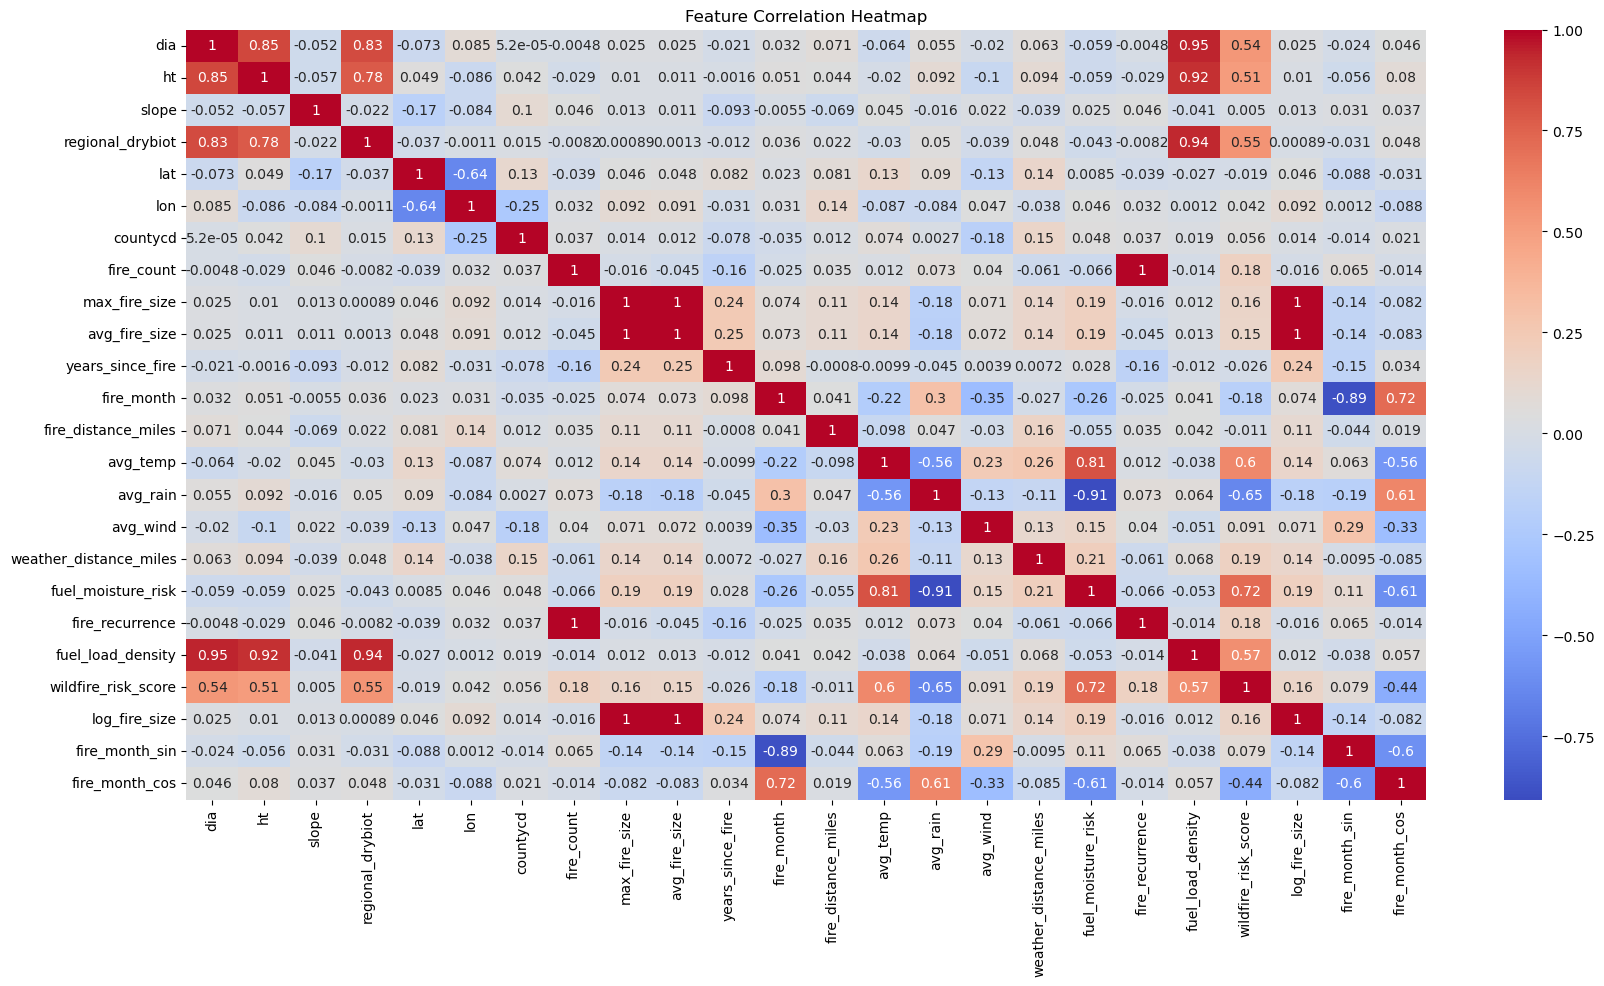

In [ ]:
#Visualise the final ML table correlation with each other
corr = vegetation_risk_data.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Our feature selection for model training will be based on the Correlation analysis from the plot . Only strong relationships with the target, among derived fire and vegetation features will be retained for training. To avoid multicollinearity and data leakage, redundant variables will be  removed before modeling.

# Connect SageMaker to S3

In [ ]:
#Create S3 client using boto3
#This allows the notebook to communicate with S3
s3 = boto3.client('s3')

#Define your S3 bucket name where your datasets are stored
bucket = "vegetation-risk-ml"

#list files inside bucket
response = s3.list_objects_v2(Bucket=bucket)


# Load ML dataset from S3

In [ ]:
vegetation_risk_data = pd.read_parquet("s3://vegetation-risk-ml/final/ml_ready/vegetation_ml_dataset.parquet")

print(vegetation_risk_data.shape)
vegetation_risk_data.head()

(243820, 25)


,dia,ht,slope,regional_drybiot,lat,lon,countycd,fire_count,max_fire_size,avg_fire_size,...,avg_wind,weather_distance_miles,fuel_moisture_risk,fire_recurrence,fuel_load_density,wildfire_risk_score,trim_priority,log_fire_size,fire_month_sin,fire_month_cos
0,10.2,46.0,35.0,404.669221,32.677701,-116.727918,73,2,263.0,156.5,...,11.297753,15.744269,15.883586,1.098612,12.154104,0.476166,High,5.575949,-1.0,-1.836970e-16
1,5.2,21.0,0.0,73.837135,32.692853,-116.508686,73,1,25.0,25.0,...,11.362007,5.792634,21.553977,0.693147,8.995167,0.331367,Medium,3.258097,-0.5,-8.660254e-01
2,6.0,23.0,0.0,108.927059,32.692853,-116.508686,73,1,25.0,25.0,...,11.362007,5.792634,21.553977,0.693147,9.617999,0.343172,Medium,3.258097,-0.5,-8.660254e-01
3,3.3,23.0,0.0,27.219884,32.761664,-116.727392,73,1,16390.0,16390.0,...,11.297753,18.134465,15.883586,0.693147,7.633848,0.257738,Low,9.704488,-1.0,-1.836970e-16
4,5.0,14.0,35.0,52.318863,32.761664,-116.727392,73,1,16390.0,16390.0,...,11.297753,18.134465,15.883586,0.693147,8.206125,0.268584,Low,9.704488,-1.0,-1.836970e-16


# Select features for training

In [ ]:
#Map trim_priority to numeric labels
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
vegetation_risk_data['target'] = vegetation_risk_data['trim_priority'].map(mapping)
if vegetation_risk_data['target'].isnull().any():
    print("Some trim_priority values were not mapped and resulted in NaN in the target column.")
else:
    print("All trim_priority values successfully mapped to target labels.")


#Save lat/lon/county before split
meta = vegetation_risk_data[['lat', 'lon', 'countycd']].copy().reset_index(drop=True)

All trim_priority values successfully mapped to target labels.


In [ ]:
# Select features and target variable
features=['dia', 'ht', 'slope', 'regional_drybiot', 'fire_recurrence', 'avg_temp', 'avg_rain', 'avg_wind', 'fuel_moisture_risk', 'log_fire_size','fire_month_sin', 'fire_month_cos']

X = vegetation_risk_data[features].reset_index(drop=True)
y = vegetation_risk_data["target"].reset_index(drop=True)


# Train Test Split

In [ ]:
#Use a stratified 70,15,15 (training,testing,validation) split to preserve class distribution across all three priority levels
#Split into 70% train, 30% temp (which will be further split into val and test)
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(X, y, X.index, test_size=0.30, random_state=42, stratify=y)

# Split temp into 15% val, 15% test
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(X_temp, y_temp, idx_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Reset indices to avoid misalignment
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Validation shape:", X_val.shape)

Train shape: (170674, 12)
Test shape: (36573, 12)
Validation shape: (36573, 12)


# Save Splits to S3

In [ ]:
#Save and upload all three splits
def save_to_s3(X, y, bucket, key):
    df = pd.concat([y.reset_index(drop=True), X.reset_index(drop=True)], axis=1)
    df.to_csv(f's3://{bucket}/{key}', header=False, index=False)

BUCKET = 'vegetation-risk-ml'
save_to_s3(X_train, y_train, BUCKET, 'ml/train/train.csv')
save_to_s3(X_val,   y_val,   BUCKET, 'ml/val/val.csv')
save_to_s3(X_test,  y_test,  BUCKET, 'ml/test/test.csv')

# Training

This project uses the SageMaker built-in XGBoost algorithm, which provides a pre-configured container for model training without requiring custom scripts or containerization

In [ ]:
#Set up SageMaker Estimator for XGBoost
role = sagemaker.get_execution_role()
session = sagemaker.Session()

# Retrieve the XGBoost container URI
container = image_uris.retrieve('xgboost', session.boto_region_name, '1.7-1')

#Create SageMaker Estimator for XGBoost
xgb = sagemaker.estimator.Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large', 
    output_path=f's3://{BUCKET}/ml/model-output/',
    disable_profiler=True,
    sagemaker_session=session
)
#Set hyperparameters for XGBoost
xgb.set_hyperparameters(
    num_class=3,
    objective='multi:softprob',
    eval_metric='mlogloss,merror',
    num_round=150,
    eta=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,    
    reg_alpha=0.1,
    seed=42
)
#Define training and validation data inputs for SageMaker
train_input = TrainingInput(f's3://{BUCKET}/ml/train/', content_type='text/csv')
val_input = TrainingInput(f's3://{BUCKET}/ml/val/', content_type='text/csv')

#Train the model
xgb.fit({'train': train_input, 'validation': val_input})
print('Training completed')

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-03-30-00-25-41-666


2026-03-30 00:25:44 Starting - Starting the training job...
2026-03-30 00:25:59 Starting - Preparing the instances for training...
2026-03-30 00:26:23 Downloading - Downloading input data...
2026-03-30 00:27:09 Downloading - Downloading the training image......
2026-03-30 00:28:15 Training - Training image download completed. Training in progress...../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-30 00:28:19.565 ip-10-0-225-241.ec2.internal:8 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-30 00:28:19.643 ip-10-0-225-241.ec2.internal:8 INFO profiler_config_parser.py:111] Unable to find config at /opt/ml/input/config/profilerconfig.json. Profiler is disabled.
[2026-03-30:00:

# Deploy

In [ ]:
#Deploy the model to an endpoint
predictor = xgb.deploy(instance_type='ml.m5.large', initial_instance_count=1)

predictor.serializer = CSVSerializer()

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-30-00-30-14-431
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-03-30-00-30-14-431
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-03-30-00-30-14-431


------!

# Evaluation

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     12191
           1       0.98      0.98      0.98     12191
           2       0.99      0.99      0.99     12191

    accuracy                           0.99     36573
   macro avg       0.99      0.99      0.99     36573
weighted avg       0.99      0.99      0.99     36573

Accuracy: 0.9881880075465508


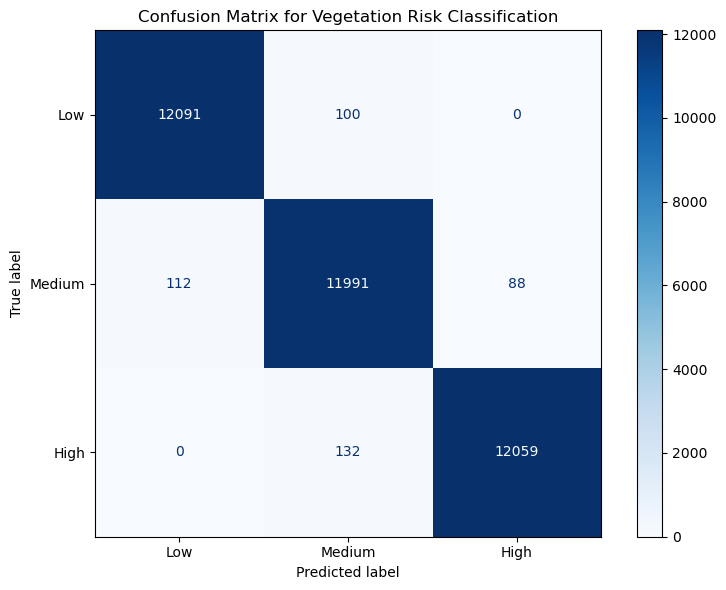

In [ ]:

# Make predictions row by row on full test set
preds = []
for i in range(len(X_test)):
    r = predictor.predict(X_test.iloc[i].values)
    if isinstance(r, (bytes, bytearray)):
        r = r.decode('utf-8')
    row = list(map(float, r.strip().split(',')))
    preds.append(row)

probs = np.array(preds)
pred_class = np.argmax(probs, axis=1)

print(classification_report(y_test, pred_class))
print("Accuracy:", accuracy_score(y_test, pred_class))

# Plot confusion matrix
cm = confusion_matrix(y_test, pred_class)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix for Vegetation Risk Classification')
plt.tight_layout()
plt.show()

# Feature Importance

In [ ]:
# Get model path from SageMaker
model_path = xgb.latest_training_job.describe()['ModelArtifacts']['S3ModelArtifacts']
print("Model:", model_path)

# Extract bucket & key automatically
bucket = model_path.split('/')[2]
key = '/'.join(model_path.split('/')[3:])

# Download model
boto3.client('s3').download_file(bucket, key, 'model.tar.gz')

# Extract model
with tarfile.open('model.tar.gz') as tar:
    tar.extractall()
    
#save feature map
feature_map_path = 'xgboost.fmap'
with open(feature_map_path, 'w') as f:
    for i, col in enumerate(X.columns):
        f.write(f"{i}\t{col}\tq\n")

# Load model
model = xgb_lib.Booster()
model.load_model('xgboost-model')
model.feature_names = list(X.columns)

Model: s3://vegetation-risk-ml/ml/model-output/sagemaker-xgboost-2026-03-30-00-25-41-666/output/model.tar.gz


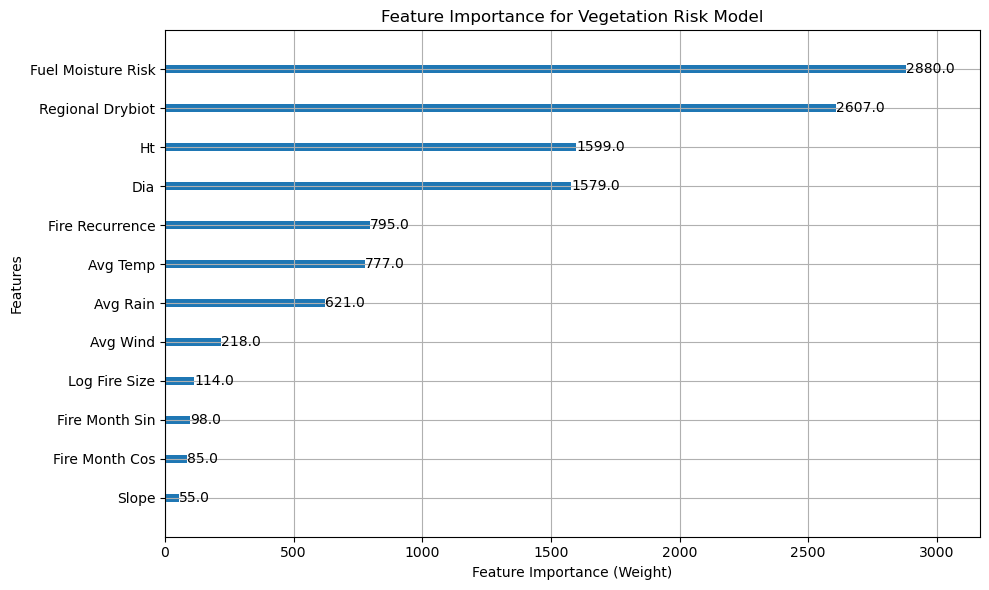

Feature Importance from Highest to Lowest:

fuel_moisture_risk : 2880.0
regional_drybiot : 2607.0
ht : 1599.0
dia : 1579.0
fire_recurrence : 795.0
avg_temp : 777.0
avg_rain : 621.0
avg_wind : 218.0
log_fire_size : 114.0
fire_month_sin : 98.0
fire_month_cos : 85.0
slope : 55.0


In [ ]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
xgb_lib.plot_importance(
    model,
    ax=ax,
    max_num_features=12,
    importance_type='weight',
    title='Feature Importance for Vegetation Risk Model',
    xlabel='Feature Importance (Weight)',
    show_values=True,
)
# y-axis tick labels
ax.set_yticklabels([t.get_text().replace('_', ' ').title()
                    for t in ax.get_yticklabels()])
plt.tight_layout()
plt.show()

# Print features
importance_dict  = model.get_score(importance_type='weight')
sorted_importance = sorted(importance_dict.items(),key=lambda x: x[1], reverse=True)
print("Feature Importance from Highest to Lowest:\n")
for name, score in sorted_importance:
    print(f"{name} : {score}")

# Monitor Training with CloudWatch

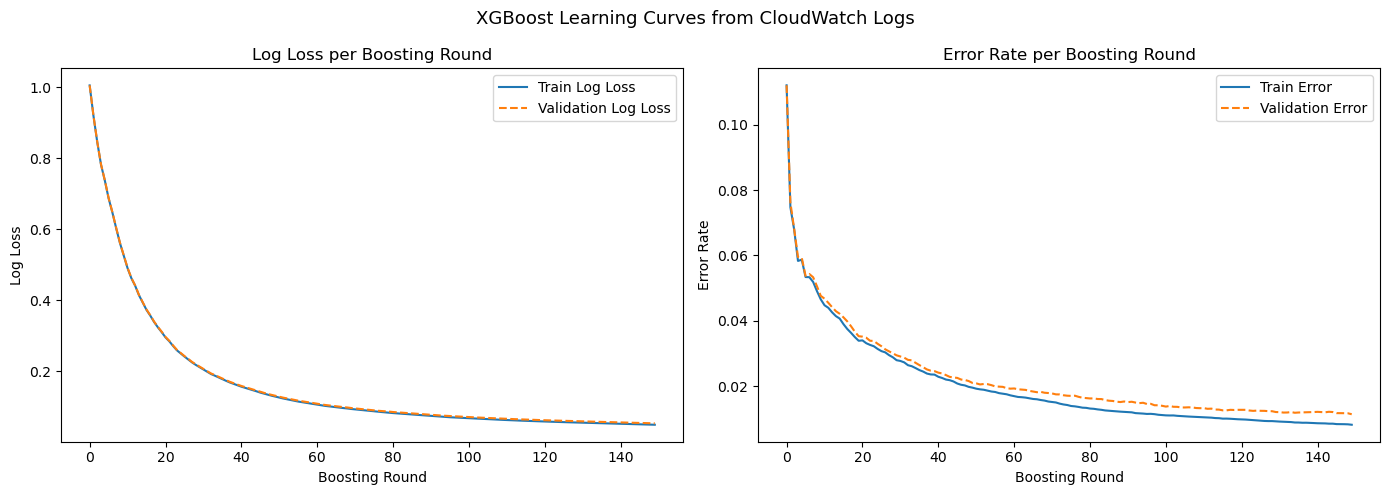


 Final Model Performance:
Train Log Loss:      0.04897
Validation Log Loss: 0.05296
Train Error:         0.00814 (0.81%)
Validation Error:    0.01135 (1.14%)
Generalization Gap:  0.32%


In [ ]:

#Connect to CloudWatch Logs

logs_client = boto3.client('logs')
log_group = '/aws/sagemaker/TrainingJobs'
job_name = xgb.latest_training_job.name

#Get Latest Log Stream for the Job
response = logs_client.describe_log_streams(
    logGroupName=log_group,
    logStreamNamePrefix=job_name
)

streams = response.get('logStreams', [])

if not streams:
    print("No log streams found for this training job")
else:
    # Select most recent log stream
    log_stream = sorted(
        streams,
        key=lambda x: x.get('lastEventTimestamp', 0),
        reverse=True
    )[0]['logStreamName']

    # Retrieve All Log Events
    all_events = []
    next_token = None

    while True:
        kwargs = {
            'logGroupName': log_group,
            'logStreamName': log_stream,
            'startFromHead': True
        }

        if next_token:
            kwargs['nextToken'] = next_token

        response = logs_client.get_log_events(**kwargs)

        all_events.extend(response.get('events', []))

        # Stop when no new logs
        if next_token == response.get('nextForwardToken'):
            break

        next_token = response.get('nextForwardToken')
    #Extract Training Metrics from Logs
    train_mlogloss = []
    val_mlogloss   = []
    train_merror   = []
    val_merror     = []

    for event in all_events:
        msg = event['message']

        try:
            if 'train-mlogloss' in msg:
                match = re.search(r'train-mlogloss:([0-9\.]+)', msg)
                if match:
                    train_mlogloss.append(float(match.group(1)))

            if 'validation-mlogloss' in msg:
                match = re.search(r'validation-mlogloss:([0-9\.]+)', msg)
                if match:
                    val_mlogloss.append(float(match.group(1)))

            if 'train-merror' in msg:
                match = re.search(r'train-merror:([0-9\.]+)', msg)
                if match:
                    train_merror.append(float(match.group(1)))

            if 'validation-merror' in msg:
                match = re.search(r'validation-merror:([0-9\.]+)', msg)
                if match:
                    val_merror.append(float(match.group(1)))

        except:
            continue
    #Validate Extracted Data
    if len(train_mlogloss) == 0:
        print("No training metrics found in logs")
    else:
        # Ensure equal lengths
        min_len = min(
            len(train_mlogloss),
            len(val_mlogloss),
            len(train_merror),
            len(val_merror)
        )

        train_mlogloss = train_mlogloss[:min_len]
        val_mlogloss   = val_mlogloss[:min_len]
        train_merror   = train_merror[:min_len]
        val_merror     = val_merror[:min_len]

        rounds = list(range(min_len))
  
        #Plot Learning Curves
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # Log Loss Plot
        axes[0].plot(rounds, train_mlogloss, label='Train Log Loss')
        axes[0].plot(rounds, val_mlogloss, label='Validation Log Loss', linestyle='--')
        axes[0].set_title('Log Loss per Boosting Round')
        axes[0].set_xlabel('Boosting Round')
        axes[0].set_ylabel('Log Loss')
        axes[0].legend()
        # Error Rate Plot
        axes[1].plot(rounds, train_merror, label='Train Error')
        axes[1].plot(rounds, val_merror, label='Validation Error', linestyle='--')
        axes[1].set_title('Error Rate per Boosting Round')
        axes[1].set_xlabel('Boosting Round')
        axes[1].set_ylabel('Error Rate')
        axes[1].legend()
        plt.suptitle('XGBoost Learning Curves from CloudWatch Logs', fontsize=13)
        plt.tight_layout()
        plt.show()

        #Print Final Metrics
        print("\n Final Model Performance:")
        print(f"Train Log Loss:      {train_mlogloss[-1]:.5f}")
        print(f"Validation Log Loss: {val_mlogloss[-1]:.5f}")
        print(f"Train Error:         {train_merror[-1]:.5f} ({train_merror[-1]*100:.2f}%)")
        print(f"Validation Error:    {val_merror[-1]:.5f} ({val_merror[-1]*100:.2f}%)")
        gap = abs(val_merror[-1] - train_merror[-1]) * 100
        print(f"Generalization Gap:  {gap:.2f}%")

The final results show that the model performed very well, with train log loss = 0.04897 and validation log loss = 0.05296, indicating strong learning.

The training error is 0.81% and validation error is 1.14%, which are both very low. The generalization gap is only 0.32%, meaning there is very little difference between training and validation performance.

This shows that the model is not overfitting and can perform well on new, unseen data.

# Batch Inference

In [ ]:
# Save full data
X.to_csv('batch.csv', header=False, index=False)

# Upload to S3
boto3.client('s3').upload_file('batch.csv', BUCKET,'ml/batch-input/batch.csv')

#Set up batch transform job
transformer = xgb.transformer(
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://{BUCKET}/ml/batch-output/',
    accept='text/csv'
)

#Start batch transform job on the full dataset
transformer.transform(
    data=f's3://{BUCKET}/ml/batch-input/',
    content_type='text/csv',
    split_type='Line'
)
#Wait for the batch transform job to complete
transformer.wait()

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-30-00-50-33-482
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-03-30-00-50-34-226


................................./miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-30:00:56:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-30:00:56:03:INFO] No GPUs detected (normal if no gpus installed)
[2026-03-30:00:56:03:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|i

# Process Batch Output

In [ ]:
#Read batch predictions from S3
batch_preds = pd.read_csv(f's3://{BUCKET}/ml/batch-output/batch.csv.out',header=None)
print(batch_preds.head())

                        0         1                         2
0  [0.0001506845437688753  0.036072       0.9637771248817444]
1    [0.01644289493560791  0.983169   0.00038767815567553043]
2   [0.004510614089667797  0.994905    0.0005847361753694713]
3     [0.9980522394180298  0.001943    4.648223693948239e-06]
4     [0.9983490705490112  0.001647    4.054565124533838e-06]


The batch prediction results are read from Amazon S3.The output is initially stored as text with brackets, so the we need to cleans the data by removing the brackets and converting the values into numeric format.Next, the probabilities are converted into a structured array.he predicted class is then calculated using argmax.Finally, a risk score is computed.This creates a continuous score (0–100), which helps rank locations based on severity.

In [ ]:
# Get predicted class labels and risk scores from batch predictions
probs = batch_preds.copy()

probs[0] = probs[0].astype(str).str.replace('[', '', regex=False)
probs[2] = probs[2].astype(str).str.replace(']', '', regex=False)

# Convert to float
probs = probs.astype(float).values

# Predicted class is the one with highest probability
pred_class = np.argmax(probs, axis=1)
risk_score = probs[:, 1] * 50 + probs[:, 2] * 100


Now combine the model predictions with the original dataset to make the results useful for analysis.the columns are reordered to include important fields like location (lat, lon, county) along with prediction results.Finally, the data is sorted by risk_score in descending order.

In [ ]:
# Combine predictions with original data for analysis
results = vegetation_risk_data.copy()

# Add predictions and risk scores to results dataframe
results['predicted_class'] = pred_class
results['priority'] = pd.Series(pred_class).map({0:'Low',1:'Medium',2:'High'})
results['risk_score'] = risk_score.round(2)

# Reorder columns for better readability
results = results[features + ['lat', 'lon', 'countycd', 'priority', 'risk_score']]

# Sort results by risk score to identify highest risk areas
results = results.sort_values('risk_score', ascending=False)

print(results.head())


         dia     ht  slope  regional_drybiot  fire_recurrence   avg_temp  \
113769  39.4   98.0   55.0       9499.979096         0.693147  29.156305   
113768  30.0  108.0   55.0       6222.471639         0.693147  29.156305   
113763  16.6   92.0   55.0       1681.913042         0.693147  29.156305   
113764  24.0   65.0   53.0       2432.080740         0.693147  29.156305   
113765  24.5   95.0   53.0       3186.055238         0.693147  29.156305   

        avg_rain   avg_wind  fuel_moisture_risk  log_fire_size  \
113769  0.002346  11.024633           29.088063       3.044522   
113768  0.002346  11.024633           29.088063       3.044522   
113763  0.002346  11.024633           29.088063       3.044522   
113764  0.002346  11.024633           29.088063       3.044522   
113765  0.002346  11.024633           29.088063       3.044522   

        fire_month_sin  fire_month_cos        lat         lon  countycd  \
113769            -0.5       -0.866025  39.526948 -122.672546        21

In [ ]:
# Verify class distribution looks reasonable
print(results['priority'].value_counts())
print(results['risk_score'].describe())

priority
Medium    81574
Low       81168
High      81078
Name: count, dtype: int64
count    243820.000000
mean         49.997013
std          39.840948
min           0.000000
25%           0.520000
50%          50.050000
75%          99.390000
max         100.000000
Name: risk_score, dtype: float64


# Save the results to S3

In [ ]:
# Save predictions to S3
s3 = boto3.client('s3')

csv_buffer = results.to_csv(index=False)
s3.put_object(Bucket=BUCKET,Key='ml/predictions/test_predictions.csv',Body=csv_buffer)

print(" Test predictions saved")

 Test predictions saved


# Delete any endpoint

In [ ]:
sagemaker_client = boto3.client('sagemaker')

# List all endpoints
endpoints = sagemaker_client.list_endpoints()

if endpoints['Endpoints']:
    for endpoint in endpoints['Endpoints']:
        name = endpoint['EndpointName']
        sagemaker_client.delete_endpoint(EndpointName=name)
        print(f"Deleted: {name}")
else:
    print("No endpoints to delete")

No endpoints to delete
